# Seleção de Meta-Features com Algoritmos Genéticos
## Projeto Final — Meta-aprendizagem
### Universidade Federal de Alagoas — Instituto de Computação

**Professor:** Lucas Amorim

---

## Resumo

Este projeto investiga o efeito da **seleção de meta-features** na performance de sistemas de
meta-aprendizagem. Partindo do **Exemplo 3** da disciplina (22 datasets, 56 meta-features),
expandimos o meta-dataset com mais datasets do OpenML e com **múltiplos grupos e medidas de
resumo** do `pymfe`, chegando a um conjunto com ~150–200 meta-features. Aplicamos
**Algoritmos Genéticos (GA)** para selecionar o subconjunto ótimo e avaliamos o impacto na
performance do meta-modelo.

**Perguntas de pesquisa:**
1. A seleção de meta-features via GA melhora a performance do meta-modelo?
2. Qual subconjunto de meta-features é selecionado?
3. As features selecionadas pelo GA são consistentes com a importância reportada por um Random Forest?

In [22]:
!pip install openml pymfe scikit-learn numpy pandas matplotlib seaborn scipy requests -q

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, time, json, pickle, io, requests

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from scipy.stats import spearmanr, wilcoxon

import openml
from pymfe.mfe import MFE

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [24]:
# ── PARÂMETROS GLOBAIS ──────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# URLs dos CSVs do Exemplo 3 (professor)
URL_PERFS = ("https://raw.githubusercontent.com/amorimlb/"
             "Meta-aprendizagem-2026.1-code/main/Example3/classifier_performances.csv")
URL_MFS   = ("https://raw.githubusercontent.com/amorimlb/"
             "Meta-aprendizagem-2026.1-code/main/Example3/dataset_meta_features.csv")

# pymfe: todos os grupos + múltiplas medidas de resumo
MFE_GROUPS   = ["general", "statistical", "info-theory", "model-based", "complexity"]
MFE_SUMMARY  = ["mean", "sd", "min", "max"]   # múltiplas medidas → expande o conjunto

# Algoritmos base (mesmos do Exemplo 3)
BASE_ALGORITHMS = {
    'DecisionTree'      : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'SVM'               : SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Perceptron'        : Perceptron(max_iter=500, random_state=RANDOM_STATE),
    'MLP'               : MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
}
ALG_COLS = list(BASE_ALGORITHMS.keys())

# Parâmetros de coleta
N_EXTRA_DATASETS = 20   # datasets extras do OpenML CC18
MAX_INSTANCES    = 5000
MIN_INSTANCES    = 80
MAX_FEATURES     = 100
CV_BASE          = 5
CV_META          = 10

# Parâmetros do GA
GA_POP_SIZE  = 30
GA_N_GEN     = 50
GA_CROSSOVER = 0.8
GA_MUTATION  = 0.05
GA_ELITE     = 2

CACHE_FILE   = "meta_dataset_cache.pkl"
CSV_FILE     = "meta_dataset.csv"
GA_FILE      = "ga_results.json"

print(f"Grupos pymfe      : {MFE_GROUPS}")
print(f"Medidas de resumo : {MFE_SUMMARY}")
print(f"Algoritmos base   : {ALG_COLS}")
print(f"GA — pop={GA_POP_SIZE} | ger={GA_N_GEN} | cx={GA_CROSSOVER} | mut={GA_MUTATION}")

Grupos pymfe      : ['general', 'statistical', 'info-theory', 'model-based', 'complexity']
Medidas de resumo : ['mean', 'sd', 'min', 'max']
Algoritmos base   : ['DecisionTree', 'SVM', 'KNN', 'LogisticRegression', 'Perceptron', 'MLP']
GA — pop=30 | ger=50 | cx=0.8 | mut=0.05


---
## Seção 1 — Construção do Meta-Dataset

### Estratégia de Expansão a partir do Exemplo 3

O **Exemplo 3** da disciplina possui 22 datasets e 56 meta-features (`.mean` de 4 grupos pymfe).
Para o Tema 4, expandimos em duas dimensões:

| Dimensão | Exemplo 3 (base) | Este projeto |
|---|---|---|
| Nº de datasets | 22 | 22 + ~20 extras do CC18 |
| Grupos pymfe | 4 (general, statistical, info-theory, clustering) | 5 (+ model-based, complexity) |
| Medidas de resumo | `.mean` | `.mean`, `.sd`, `.min`, `.max` |
| Nº de meta-features | ~56 | ~150–200 |

### Pipeline

```
CSVs do Exemplo 3 (22 datasets, 56 mfs, 6 classificadores)
        ↓
Datasets originais (OpenML) + extras do CC18
        ↓
pymfe — todos os grupos + 4 medidas de resumo → ~150-200 meta-features
        ↓
5-fold CV dos 6 classificadores (novos datasets)
        ↓
meta_dataset.csv  →  GA  →  meta-modelo otimizado
```

In [25]:
# ── 1.1  Carregar dados do Exemplo 3 (professor) ───────────────────────────
print("Carregando CSVs do Exemplo 3...")
perfs_ex3 = pd.read_csv(URL_PERFS)
mfs_ex3   = pd.read_csv(URL_MFS, index_col=0)

print(f"classifier_performances.csv : {perfs_ex3.shape}  "
      f"(colunas: {list(perfs_ex3.columns)})")
print(f"dataset_meta_features.csv   : {mfs_ex3.shape}  "
      f"({len(mfs_ex3.columns)} meta-features, {len(mfs_ex3)} datasets)")

# Datasets do exemplo 3
ex3_datasets = list(mfs_ex3.index)
print(f"\n22 datasets do Exemplo 3:")
for i, d in enumerate(ex3_datasets, 1):
    print(f"  {i:2d}. {d}")

Carregando CSVs do Exemplo 3...
classifier_performances.csv : (132, 11)  (colunas: ['Dataset', 'Classifier', 'acc_fold1', 'acc_fold2', 'acc_fold3', 'acc_fold4', 'acc_fold5', 'acc_mean', 'acc_stddev', 'train_time', 'test_time'])
dataset_meta_features.csv   : (22, 56)  (56 meta-features, 22 datasets)

22 datasets do Exemplo 3:
   1. diabetes
   2. blood-transfusion-service-center
   3. monks-problems-2
   4. tic-tac-toe
   5. titanic
   6. pc1
   7. kr-vs-kp
   8. phoneme
   9. wdbc
  10. semeion
  11. isolet
  12. cnae-9
  13. ilpd-numeric
  14. students_scores
  15. usps
  16. ibm-employee-performance
  17. mushroom
  18. segment
  19. autoUniv-au1-1000
  20. pizzacutter3
  21. qsar
  22. solar-flare


In [26]:
def extrair_meta_features(X_arr, y_arr, groups, summary, random_state=42):
    """Extrai meta-features com pymfe para os grupos e medidas de resumo especificados."""
    try:
        mfe = MFE(groups=groups, summary=summary,
                  random_state=random_state, suppress_warnings=True)
        mfe.fit(X_arr, y_arr, suppress_warnings=True)
        names, values = mfe.extract(suppress_warnings=True)
        return dict(zip(names, values))
    except Exception as e:
        return {}


def preparar_dataset_openml(dataset_id, target_name=None):
    """Baixa um dataset do OpenML e retorna X_imp, y_enc."""
    ds = openml.datasets.get_dataset(dataset_id, download_data=True)
    tgt = target_name or ds.default_target_attribute
    X, y, _, _ = ds.get_data(target=tgt, dataset_format='dataframe')

    for col in X.columns:
        if X[col].dtype == 'object' or str(X[col].dtype) == 'category':
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.astype(float)
    y_enc = LabelEncoder().fit_transform(y.astype(str))
    X_imp = SimpleImputer(strategy='mean').fit_transform(X.values)
    return X_imp, y_enc, ds.name


def avaliar_classificadores(X_imp, y_enc, algorithms, cv_folds=5, random_state=42):
    """Avalia todos os algoritmos base com k-fold CV estratificado."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    perf = {}
    for name, alg in algorithms.items():
        sc = cross_val_score(alg, X_imp, y_enc, cv=cv,
                             scoring='accuracy', n_jobs=-1)
        perf[name] = float(sc.mean())
    return perf


print("Funções auxiliares definidas.")

Funções auxiliares definidas.


In [27]:
def coletar_meta_dataset(ex3_datasets, n_extra, max_inst, min_inst, max_feat,
                          mfe_groups, mfe_summary, base_algorithms,
                          cv_base, random_state, cache_file):
    if os.path.exists(cache_file):
        print(f"Cache encontrado — carregando '{cache_file}'...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    meta_rows, perf_rows = [], []

    # ── Parte A: datasets do Exemplo 3 ─────────────────────────────────────
    print("=== PARTE A: datasets do Exemplo 3 (22 datasets) ===")
    search = openml.datasets.list_datasets(output_format='dataframe')

    for ds_name in ex3_datasets:
        try:
            row_match = search[search['name'] == ds_name]
            if len(row_match) == 0:
                print(f"  !! Nao encontrado no OpenML: {ds_name}")
                continue
            ds_id  = int(row_match.iloc[0]['did'])
            X_imp, y_enc, name = preparar_dataset_openml(ds_id)

            if not (min_inst <= X_imp.shape[0] <= max_inst): continue
            if X_imp.shape[1] < 2 or X_imp.shape[1] > max_feat: continue

            mf_row = extrair_meta_features(X_imp, y_enc, mfe_groups,
                                            mfe_summary, random_state)
            if not mf_row:
                continue
            mf_row['dataset_name'] = name
            mf_row['n_inst']       = X_imp.shape[0]
            mf_row['n_feat']       = X_imp.shape[1]
            meta_rows.append(mf_row)

            pf = avaliar_classificadores(X_imp, y_enc, base_algorithms,
                                          cv_base, random_state)
            pf['dataset_name'] = name
            perf_rows.append(pf)
            print(f"  [A] {name:<42s} shape=({X_imp.shape[0]},{X_imp.shape[1]})  "
                  f"LR={pf.get('LogisticRegression', 0):.3f}")
        except Exception as e:
            print(f"  !! Erro em {ds_name}: {e}")
            continue

    # ── Parte B: datasets extras do CC18 ───────────────────────────────────
    # OpenML-CC18 é uma benchmark suite
    print(f"\n=== PARTE B: {n_extra} datasets extras do OpenML CC18 ===")
    task_ids = []
    try:
        suite    = openml.study.get_suite('OpenML-CC18')
        task_ids = list(suite.tasks)
        print(f"  CC18 carregado via get_suite() — {len(task_ids)} tasks")
    except Exception as e1:
        print(f"  get_suite() falhou ({e1}), tentando list_tasks(tag=)...")
        try:
            tasks_df = openml.tasks.list_tasks(tag='OpenML-CC18', output_format='dataframe')
            task_ids = list(tasks_df.index)
            print(f"  CC18 carregado via list_tasks(tag=) — {len(task_ids)} tasks")
        except Exception as e2:
            print(f"  !! Nao foi possivel carregar CC18: {e2}")

    done_names  = {r['dataset_name'] for r in meta_rows}
    extra_count = 0

    for tid in task_ids:
        if extra_count >= n_extra:
            break
        try:
            task = openml.tasks.get_task(tid)
            X_imp, y_enc, name = preparar_dataset_openml(task.dataset_id,
                                                           task.target_name)
            if name in done_names:
                continue
            if not (min_inst <= X_imp.shape[0] <= max_inst):
                continue
            if X_imp.shape[1] < 2 or X_imp.shape[1] > max_feat:
                continue

            mf_row = extrair_meta_features(X_imp, y_enc, mfe_groups,
                                            mfe_summary, random_state)
            if not mf_row:
                continue
            mf_row['dataset_name'] = name
            mf_row['n_inst']       = X_imp.shape[0]
            mf_row['n_feat']       = X_imp.shape[1]
            meta_rows.append(mf_row)

            pf = avaliar_classificadores(X_imp, y_enc, base_algorithms,
                                          cv_base, random_state)
            pf['dataset_name'] = name
            perf_rows.append(pf)
            done_names.add(name)
            extra_count += 1
            print(f"  [B] {name:<42s} shape=({X_imp.shape[0]},{X_imp.shape[1]})  "
                  f"LR={pf.get('LogisticRegression', 0):.3f}")
        except Exception:
            continue

    meta_df = pd.DataFrame(meta_rows)
    perf_df = pd.DataFrame(perf_rows)
    result  = {'meta_df': meta_df, 'perf_df': perf_df}
    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)
    print(f"\nCache salvo em '{cache_file}'")
    return result


data = coletar_meta_dataset(
    ex3_datasets   = ex3_datasets,
    n_extra        = N_EXTRA_DATASETS,
    max_inst       = MAX_INSTANCES,
    min_inst       = MIN_INSTANCES,
    max_feat       = MAX_FEATURES,
    mfe_groups     = MFE_GROUPS,
    mfe_summary    = MFE_SUMMARY,
    base_algorithms= BASE_ALGORITHMS,
    cv_base        = CV_BASE,
    random_state   = RANDOM_STATE,
    cache_file     = CACHE_FILE,
)
meta_df = data['meta_df']
perf_df = data['perf_df']
print(f"\nTotal de datasets coletados: {len(meta_df)}")

Cache encontrado — carregando 'meta_dataset_cache.pkl'...

Total de datasets coletados: 35


In [28]:
ID_COLS = ['dataset_name', 'n_inst', 'n_feat']

feature_names = np.array([c for c in meta_df.columns if c not in ID_COLS])

# Remover colunas 100% NaN antes de imputar (ex: num_to_cat)
raw_vals      = meta_df[feature_names].values.astype(float)
valid_mask    = ~np.all(np.isnan(raw_vals), axis=0)
feature_names = feature_names[valid_mask]

# Imputar valores faltantes nas meta-features
imp_meta   = SimpleImputer(strategy='median')
X_meta     = imp_meta.fit_transform(meta_df[feature_names].values.astype(float))
y_best_alg = perf_df[ALG_COLS].max(axis=1).values

# Também guardar acurácias individuais
full_df = meta_df[ID_COLS].copy()
for fn in feature_names:
    full_df[fn] = meta_df[fn].values
for alg in ALG_COLS:
    full_df[alg] = perf_df[alg].values

full_df.to_csv(CSV_FILE, index=False)

print(f"Meta-dataset expandido:")
print(f"  Datasets         : {X_meta.shape[0]}")
print(f"  Meta-features    : {X_meta.shape[1]}")
print(f"  Algoritmos base  : {len(ALG_COLS)}")
print(f"  CSV salvo        : {CSV_FILE}")
print()

# ── Comparação com o Exemplo 3 ──────────────────────────────────────────────
print("=== COMPARAÇÃO: EXEMPLO 3 vs META-DATASET EXPANDIDO ===")
comp_exp3 = pd.DataFrame({
    'Dimensão'          : ['Nº de datasets', 'Nº de meta-features',
                            'Grupos pymfe', 'Medidas de resumo'],
    'Exemplo 3 (base)'  : [22, len(mfs_ex3.columns), '4 grupos', 'mean'],
    'Este projeto'      : [X_meta.shape[0], X_meta.shape[1],
                            f'{len(MFE_GROUPS)} grupos',
                            ', '.join(MFE_SUMMARY)],
})
print(comp_exp3.to_string(index=False))
print()
print("Primeiros 8 datasets:")
print(full_df[['dataset_name','n_inst','n_feat']+ALG_COLS].head(8).round(3).to_string(index=False))

Meta-dataset expandido:
  Datasets         : 35
  Meta-features    : 224
  Algoritmos base  : 6
  CSV salvo        : meta_dataset.csv

=== COMPARAÇÃO: EXEMPLO 3 vs META-DATASET EXPANDIDO ===
           Dimensão Exemplo 3 (base)       Este projeto
     Nº de datasets               22                 35
Nº de meta-features               56                224
       Grupos pymfe         4 grupos           5 grupos
  Medidas de resumo             mean mean, sd, min, max

Primeiros 8 datasets:
                    dataset_name  n_inst  n_feat  DecisionTree   SVM   KNN  LogisticRegression  Perceptron   MLP
                        diabetes     768       8         0.702 0.760 0.698               0.771       0.575 0.659
blood-transfusion-service-center     748       4         0.730 0.759 0.762               0.773       0.636 0.674
                monks-problems-2     601       6         0.992 0.677 0.596               0.641       0.601 0.898
                     tic-tac-toe     958       9      

---
## Seção 2 — Análise Exploratória do Meta-Dataset

Avaliamos: distribuição dos datasets, valores faltantes nas meta-features,
correlações (redundância) e distribuição das performances dos algoritmos base.

In [29]:
# ── TABELA 1: estatísticas dos datasets ─────────────────────────────────────
print("=== ESTATÍSTICAS DOS DATASETS ===")
rows = [
    ("Total de datasets"            , X_meta.shape[0]),
    ("Total de meta-features"       , X_meta.shape[1]),
    ("Instâncias — min / max / média", f"{int(full_df['n_inst'].min())} / "
                                        f"{int(full_df['n_inst'].max())} / "
                                        f"{full_df['n_inst'].mean():.0f}"),
    ("Features   — min / max / média", f"{int(full_df['n_feat'].min())} / "
                                        f"{int(full_df['n_feat'].max())} / "
                                        f"{full_df['n_feat'].mean():.1f}"),
]
for label, val in rows:
    print(f"  {label:<40s}: {val}")

# ── TABELA 2: performance dos algoritmos base ────────────────────────────────
print("\n=== PERFORMANCE DOS ALGORITMOS BASE (acurácia, 5-fold CV) ===")
ps = []
for alg in ALG_COLS:
    v = full_df[alg]
    ps.append({'Algoritmo': alg, 'Média': f"{v.mean():.4f}",
               'Std': f"{v.std():.4f}", 'Mín': f"{v.min():.4f}",
               'Máx': f"{v.max():.4f}"})
print(pd.DataFrame(ps).to_string(index=False))

# ── TABELA 3: valores faltantes ──────────────────────────────────────────────
missing = (meta_df[feature_names].isnull().mean()*100).round(1)
n_miss  = (missing > 0).sum()
print(f"\n=== META-FEATURES COM VALORES FALTANTES: {n_miss} de {len(feature_names)} ===")
if n_miss > 0:
    dfm = missing[missing>0].sort_values(ascending=False).reset_index()
    dfm.columns = ['Meta-Feature', '% Faltante']
    print(dfm.head(15).to_string(index=False))
else:
    print("  Nenhuma.")

=== ESTATÍSTICAS DOS DATASETS ===
  Total de datasets                       : 35
  Total de meta-features                  : 224
  Instâncias — min / max / média          : 315 / 4601 / 1382
  Features   — min / max / média          : 4 / 76 / 25.0

=== PERFORMANCE DOS ALGORITMOS BASE (acurácia, 5-fold CV) ===
         Algoritmo  Média    Std    Mín    Máx
      DecisionTree 0.7921 0.1627 0.1732 1.0000
               SVM 0.7706 0.1843 0.2121 0.9917
               KNN 0.7695 0.1746 0.1882 0.9917
LogisticRegression 0.7994 0.1672 0.2258 0.9980
        Perceptron 0.6436 0.2285 0.1445 0.9798
               MLP 0.7780 0.1989 0.2234 0.9937

=== META-FEATURES COM VALORES FALTANTES: 43 de 224 ===
Meta-Feature  % Faltante
       f2.sd        68.6
  can_cor.sd        60.0
       l3.sd        60.0
       f4.sd        60.0
       f3.sd        60.0
       l1.sd        60.0
       l2.sd        60.0
      f1v.sd        60.0
    sd_ratio        57.1
      n2.max        28.6
     n2.mean        28.6
   

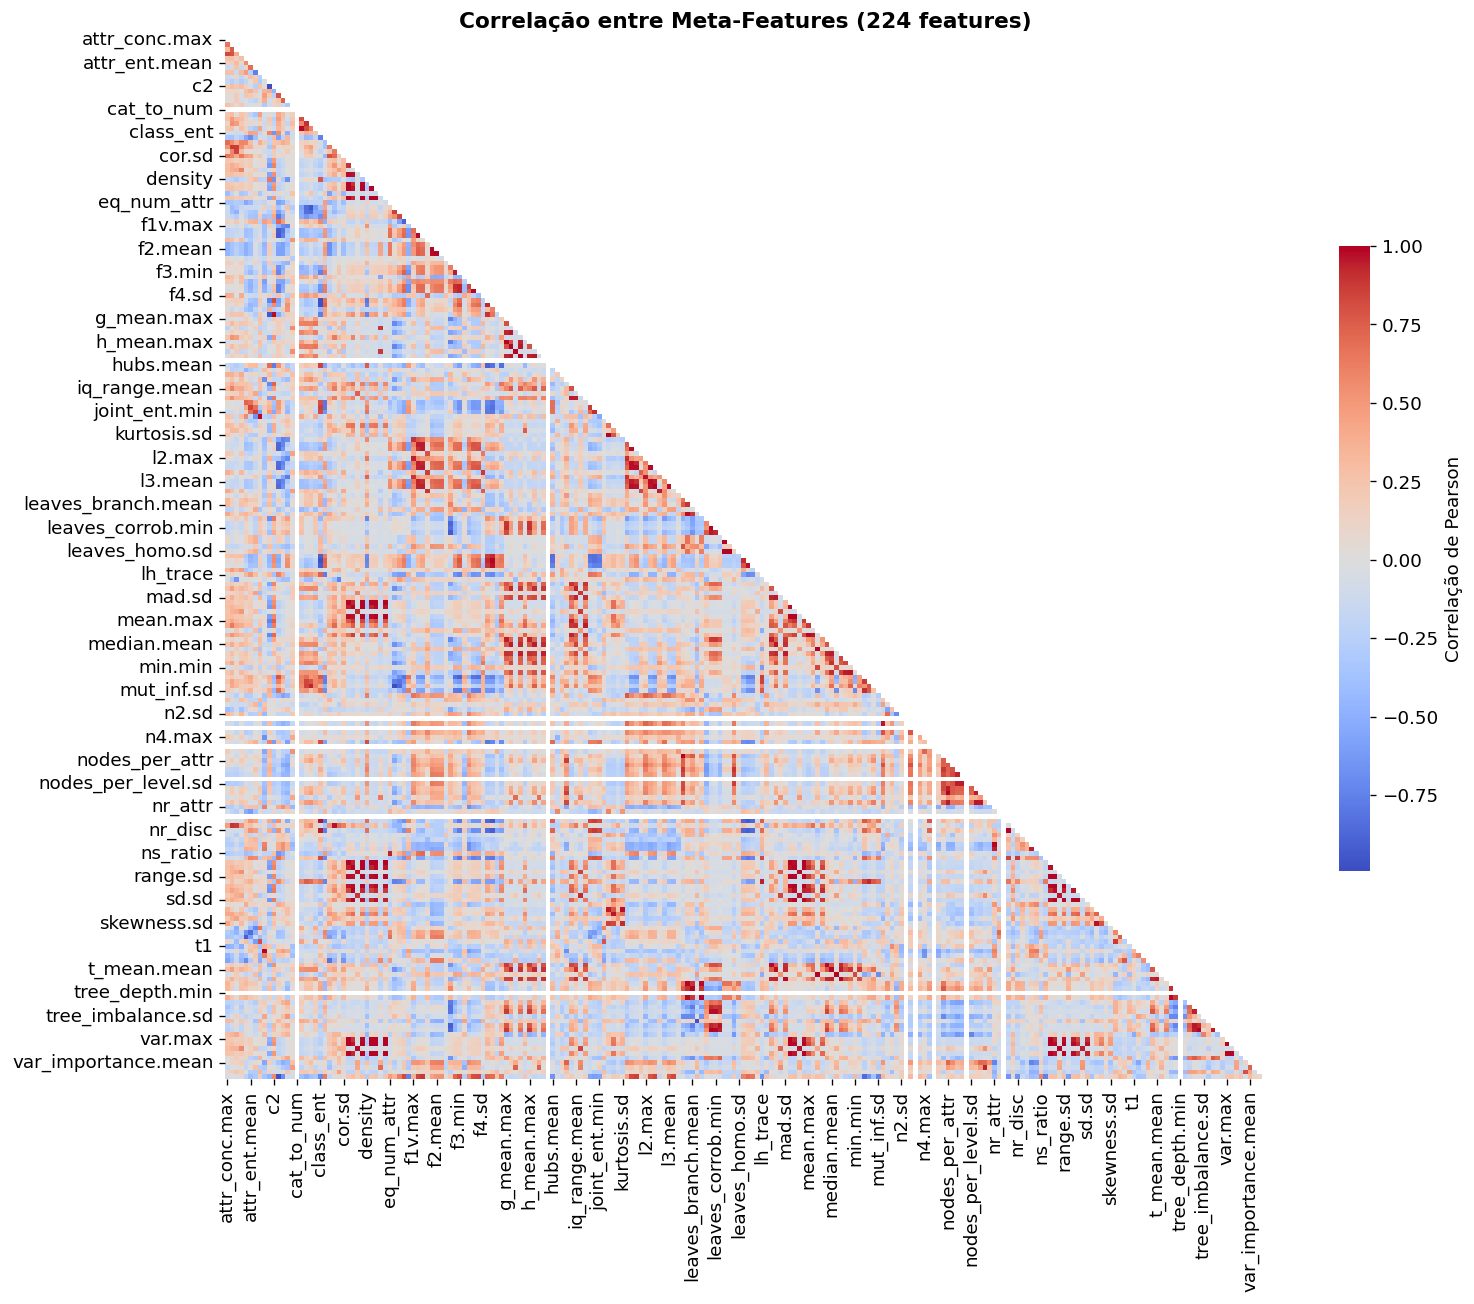

Pares com |r| > 0.9: 364  (indica redundância que o GA pode eliminar)


In [30]:
corr = pd.DataFrame(X_meta, columns=feature_names).corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0,
            cbar_kws={"shrink": 0.6, "label": "Correlação de Pearson"}, ax=ax)
ax.set_title(f"Correlação entre Meta-Features ({len(feature_names)} features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

high = sum(1 for i in range(len(feature_names))
             for j in range(i+1, len(feature_names))
             if abs(corr.iloc[i,j]) > 0.9)
print(f"Pares com |r| > 0.9: {high}  (indica redundância que o GA pode eliminar)")

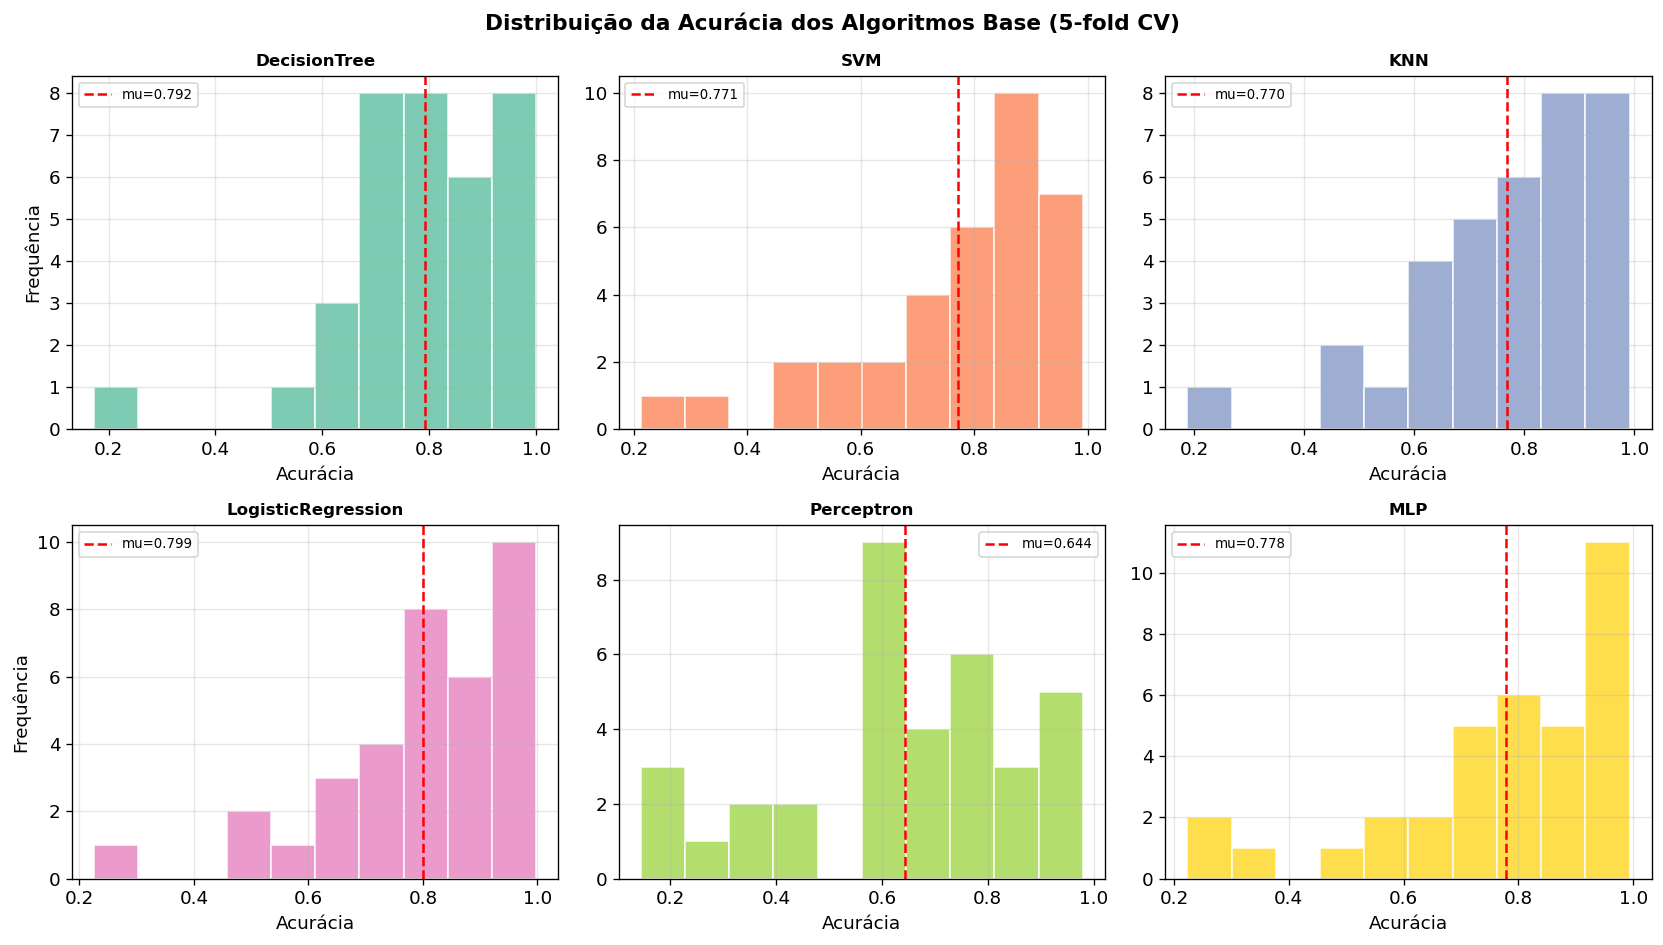

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, alg in enumerate(ALG_COLS):
    v = full_df[alg]
    axes[i].hist(v, bins=10, color=plt.cm.Set2.colors[i], alpha=0.85, edgecolor='white')
    axes[i].axvline(v.mean(), color='red', ls='--', lw=1.5, label=f'mu={v.mean():.3f}')
    axes[i].set_title(alg, fontsize=10)
    axes[i].set_xlabel('Acurácia'); axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
axes[0].set_ylabel('Frequência')
axes[3].set_ylabel('Frequência')
plt.suptitle("Distribuição da Acurácia dos Algoritmos Base (5-fold CV)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("performance_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Seção 3 — Meta-Modelo Base (Antes da Seleção de Features)

Treinamos o meta-modelo usando **todas** as meta-features expandidas como baseline.
Avaliamos com 10-fold CV usando RMSE e Spearman ρ.

Também incluímos como referência o resultado com as **56 meta-features originais** do Exemplo 3,
para quantificar o ganho da expansão mesmo antes do GA.

In [32]:
def avaliar_meta_modelo(modelo, X, y, cv=10, random_state=42):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    rmse_list, sp_list = [], []
    for tr, te in kf.split(X):
        m = clone(modelo)
        m.fit(X[tr], y[tr])
        p = m.predict(X[te])
        rmse_list.append(float(np.sqrt(np.mean((y[te]-p)**2))))
        rho, _ = spearmanr(y[te], p)
        sp_list.append(float(rho) if not np.isnan(rho) else 0.0)
    return np.mean(rmse_list), np.mean(sp_list), rmse_list, sp_list


META_MODELS = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'KNN (k=5)'   : KNeighborsRegressor(n_neighbors=5),
}
TARGET_ALGS = ALG_COLS   # prever acurácia de cada algoritmo

print("Funcao avaliar_meta_modelo definida.")

Funcao avaliar_meta_modelo definida.


In [33]:
print("="*70)
print(f"BASELINE — TODAS AS META-FEATURES EXPANDIDAS (n = {X_meta.shape[1]})")
print("="*70)
baseline_rows     = []
baseline_rf_folds = []

for mm_name, mm in META_MODELS.items():
    for alg in TARGET_ALGS:
        y_t = full_df[alg].values
        rmse, sp, rf, _ = avaliar_meta_modelo(mm, X_meta, y_t, CV_META, RANDOM_STATE)
        baseline_rows.append({'Meta-Modelo': mm_name, 'Alg. Alvo': alg,
                               'RMSE': rmse, 'Spearman': sp,
                               'N Features': X_meta.shape[1]})
        if mm_name == 'Random Forest' and alg == 'LogisticRegression':
            baseline_rf_folds = rf

baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.round(5).to_string(index=False))
baseline_df.to_csv("baseline_results.csv", index=False)

# ── Referência: Exemplo 3 (56 features do professor) ─────────────────────────
print()
print("="*70)
print(f"REFERENCIA — META-FEATURES DO EXEMPLO 3 (n = {len(mfs_ex3.columns)})")
print("="*70)
# Usar apenas datasets presentes em ambos
common_ds = list(set(full_df['dataset_name']) & set(mfs_ex3.index))
X_ex3_raw = mfs_ex3.loc[common_ds].values.astype(float)
X_ex3     = SimpleImputer(strategy='median').fit_transform(X_ex3_raw)
y_ex3_lr  = full_df.set_index('dataset_name').loc[common_ds]['LogisticRegression'].values

ref_rows = []
for mm_name, mm in META_MODELS.items():
    rmse, sp, _, _ = avaliar_meta_modelo(mm, X_ex3, y_ex3_lr, CV_META, RANDOM_STATE)
    ref_rows.append({'Meta-Modelo': mm_name, 'Alg. Alvo': 'LogisticRegression',
                      'RMSE': rmse, 'Spearman': sp, 'N Features': X_ex3.shape[1],
                      'Nota': 'Exemplo 3 (ref)'})
ref_df = pd.DataFrame(ref_rows)
print(ref_df.round(5).to_string(index=False))

BASELINE — TODAS AS META-FEATURES EXPANDIDAS (n = 224)
  Meta-Modelo          Alg. Alvo    RMSE  Spearman  N Features
Random Forest       DecisionTree 0.09583   0.66000         224
Random Forest                SVM 0.15502   0.46000         224
Random Forest                KNN 0.12140   0.81000         224
Random Forest LogisticRegression 0.08768   0.76000         224
Random Forest         Perceptron 0.20238   0.52000         224
Random Forest                MLP 0.15160   0.68000         224
    KNN (k=5)       DecisionTree 0.14413   0.29487         224
    KNN (k=5)                SVM 0.18318   0.26379         224
    KNN (k=5)                KNN 0.17219  -0.14149         224
    KNN (k=5) LogisticRegression 0.16337  -0.14513         224
    KNN (k=5)         Perceptron 0.21396   0.31108         224
    KNN (k=5)                MLP 0.17753   0.47325         224

REFERENCIA — META-FEATURES DO EXEMPLO 3 (n = 56)
  Meta-Modelo          Alg. Alvo    RMSE  Spearman  N Features            No

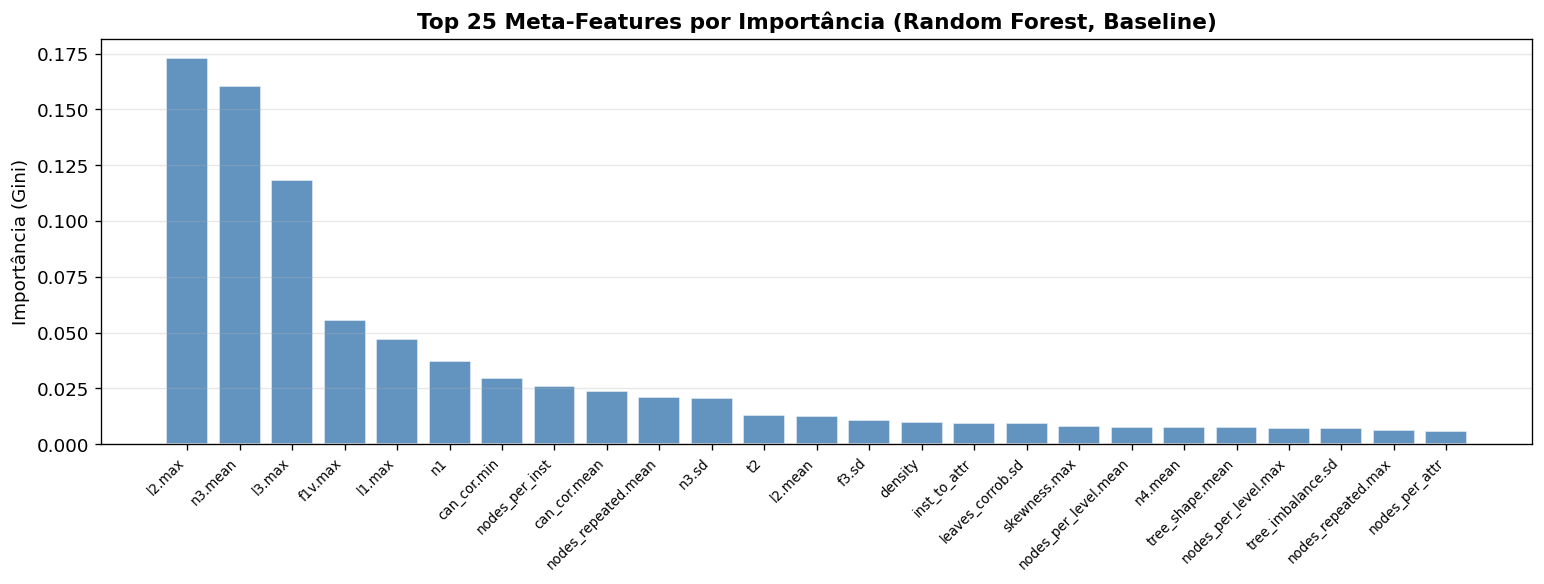

Top 5 features mais importantes (baseline):
  1. l2.max                                   0.17289
  2. n3.mean                                  0.16067
  3. l3.max                                   0.11844
  4. f1v.max                                  0.05551
  5. l1.max                                   0.04733


In [34]:
y_lr = full_df['LogisticRegression'].values
rf_base = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_base.fit(X_meta, y_lr)
importances = rf_base.feature_importances_
ord_idx     = np.argsort(importances)[::-1]
TOP_N       = min(25, len(feature_names))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(TOP_N), importances[ord_idx[:TOP_N]],
       color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticks(range(TOP_N))
ax.set_xticklabels(feature_names[ord_idx[:TOP_N]], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importância (Gini)')
ax.set_title(f'Top {TOP_N} Meta-Features por Importância (Random Forest, Baseline)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 features mais importantes (baseline):")
for i in range(5):
    print(f"  {i+1}. {feature_names[ord_idx[i]]:<40s} {importances[ord_idx[i]]:.5f}")

---
## Seção 4 — Algoritmo Genético para Seleção de Meta-Features

### Cromossomo e Fitness

```
Cromossomo:  [1, 0, 1, 1, 0, 0, 1, ...]   (comprimento = nº de meta-features)
                ↑     ↑  ↑        ↑  → gene=1: incluir
                   ↑     ↑  ↑       → gene=0: descartar

Fitness(c) = RMSE médio (5-fold CV) do meta-modelo treinado só com as features selecionadas
Objetivo   = minimizar Fitness
```

### Operadores

| Componente | Método |
|---|---|
| Inicialização | Aleatória (~50% de bits ativos) |
| Seleção | Torneio (k = 3) |
| Crossover | Single-point (taxa = 0.8) |
| Mutação | Bit-flip por gene (taxa = 0.05) |
| Elitismo | Top-2 preservados entre gerações |
| Cache | Fitness já calculada é reutilizada |

In [35]:
class GASeletorMetaFeatures:
    def __init__(self, n_features, pop_size=30, n_gen=50,
                 crossover_rate=0.8, mutation_rate=0.05, elite_size=2,
                 cv_fitness=5, random_state=42):
        self.n   = n_features
        self.ps  = pop_size
        self.ng  = n_gen
        self.cx  = crossover_rate
        self.mut = mutation_rate
        self.el  = elite_size
        self.cv  = cv_fitness
        self.rng = np.random.RandomState(random_state)
        self.cache = {}
        self.hist_best, self.hist_mean, self.hist_nf = [], [], []
        self.best_chromosome = None
        self.best_fitness    = None

    def _init(self):
        pop = []
        for _ in range(self.ps):
            ind = self.rng.randint(0, 2, self.n).astype(np.int8)
            if ind.sum() == 0:
                ind[self.rng.randint(0, self.n)] = 1
            pop.append(ind)
        return pop

    def _fit(self, chrom, X, y, model):
        key = tuple(chrom)
        if key in self.cache:
            return self.cache[key]
        sel = np.where(chrom == 1)[0]
        if len(sel) == 0:
            self.cache[key] = 999.0
            return 999.0
        Xs = X[:, sel]
        kf = KFold(n_splits=self.cv, shuffle=True,
                   random_state=int(self.rng.randint(0, 9999)))
        errs = [np.sqrt(np.mean((y[te] - clone(model).fit(Xs[tr], y[tr]).predict(Xs[te]))**2))
                for tr, te in kf.split(Xs)]
        v = float(np.mean(errs))
        self.cache[key] = v
        return v

    def _tourn(self, pop, fits, k=3):
        idx = self.rng.choice(len(pop), k, replace=False)
        return pop[min(idx, key=lambda i: fits[i])].copy()

    def _cross(self, p1, p2):
        if self.rng.random() > self.cx:
            return p1.copy(), p2.copy()
        pt = self.rng.randint(1, self.n)
        return np.concatenate([p1[:pt],p2[pt:]]), np.concatenate([p2[:pt],p1[pt:]])

    def _mutate(self, c):
        ch = c.copy()
        ch[self.rng.random(self.n) < self.mut] ^= 1
        if ch.sum() == 0:
            ch[self.rng.randint(0, self.n)] = 1
        return ch

    def evoluir(self, X, y, model, verbose=True):
        pop = self._init()
        t0  = time.time()
        for g in range(self.ng):
            fits = [self._fit(ind, X, y, model) for ind in pop]
            best = min(fits)
            bi   = int(np.argmin(fits))
            self.hist_best.append(best)
            self.hist_mean.append(float(np.mean(fits)))
            self.hist_nf.append(int(pop[bi].sum()))
            if verbose and (g == 0 or (g+1) % 10 == 0 or g == self.ng-1):
                print(f"  Gen {g+1:3d}/{self.ng} | RMSE: {best:.5f} | "
                      f"Media: {np.mean(fits):.5f} | "
                      f"Feats: {int(pop[bi].sum())}/{self.n} | "
                      f"Cache: {len(self.cache)} | {time.time()-t0:.0f}s")
            si    = np.argsort(fits)
            nova  = [pop[i].copy() for i in si[:self.el]]
            while len(nova) < self.ps:
                c1, c2 = self._cross(self._tourn(pop,fits), self._tourn(pop,fits))
                nova += [self._mutate(c1), self._mutate(c2)]
            pop = nova[:self.ps]
        fits = [self._fit(ind, X, y, model) for ind in pop]
        bi   = int(np.argmin(fits))
        self.best_chromosome = pop[bi]
        self.best_fitness    = fits[bi]
        print(f"\nConcluido em {(time.time()-t0)/60:.1f} min | "
              f"Melhor RMSE: {self.best_fitness:.5f} | "
              f"Features: {self.best_chromosome.sum()}/{self.n}")
        return self.best_chromosome

print("Classe GASeletorMetaFeatures definida.")

Classe GASeletorMetaFeatures definida.


In [36]:
model_ga = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE)

ga = GASeletorMetaFeatures(
    n_features=X_meta.shape[1], pop_size=GA_POP_SIZE, n_gen=GA_N_GEN,
    crossover_rate=GA_CROSSOVER, mutation_rate=GA_MUTATION,
    elite_size=GA_ELITE, cv_fitness=5, random_state=RANDOM_STATE)

print(f"Iniciando GA com {X_meta.shape[1]} meta-features...")
print(f"Pop={GA_POP_SIZE} | Ger={GA_N_GEN} | CX={GA_CROSSOVER} | Mut={GA_MUTATION}")
print()
best_chrom = ga.evoluir(X_meta, y_lr, model_ga, verbose=True)

with open(GA_FILE, 'w') as f:
    json.dump({'best_chromosome': best_chrom.tolist(),
               'best_fitness'   : float(ga.best_fitness),
               'hist_best': ga.hist_best, 'hist_mean': ga.hist_mean,
               'hist_nf'  : ga.hist_nf}, f, indent=2)
print(f"Resultados salvos em '{GA_FILE}'")

Iniciando GA com 224 meta-features...
Pop=30 | Ger=50 | CX=0.8 | Mut=0.05

  Gen   1/50 | RMSE: 0.08906 | Media: 0.10441 | Feats: 112/224 | Cache: 30 | 7s
  Gen  10/50 | RMSE: 0.08039 | Media: 0.09581 | Feats: 123/224 | Cache: 282 | 67s
  Gen  20/50 | RMSE: 0.08039 | Media: 0.09682 | Feats: 123/224 | Cache: 562 | 140s
  Gen  30/50 | RMSE: 0.08031 | Media: 0.09783 | Feats: 121/224 | Cache: 842 | 209s
  Gen  40/50 | RMSE: 0.07902 | Media: 0.09527 | Feats: 114/224 | Cache: 1122 | 279s
  Gen  50/50 | RMSE: 0.07902 | Media: 0.09627 | Feats: 114/224 | Cache: 1402 | 346s

Concluido em 5.9 min | Melhor RMSE: 0.07902 | Features: 114/224
Resultados salvos em 'ga_results.json'


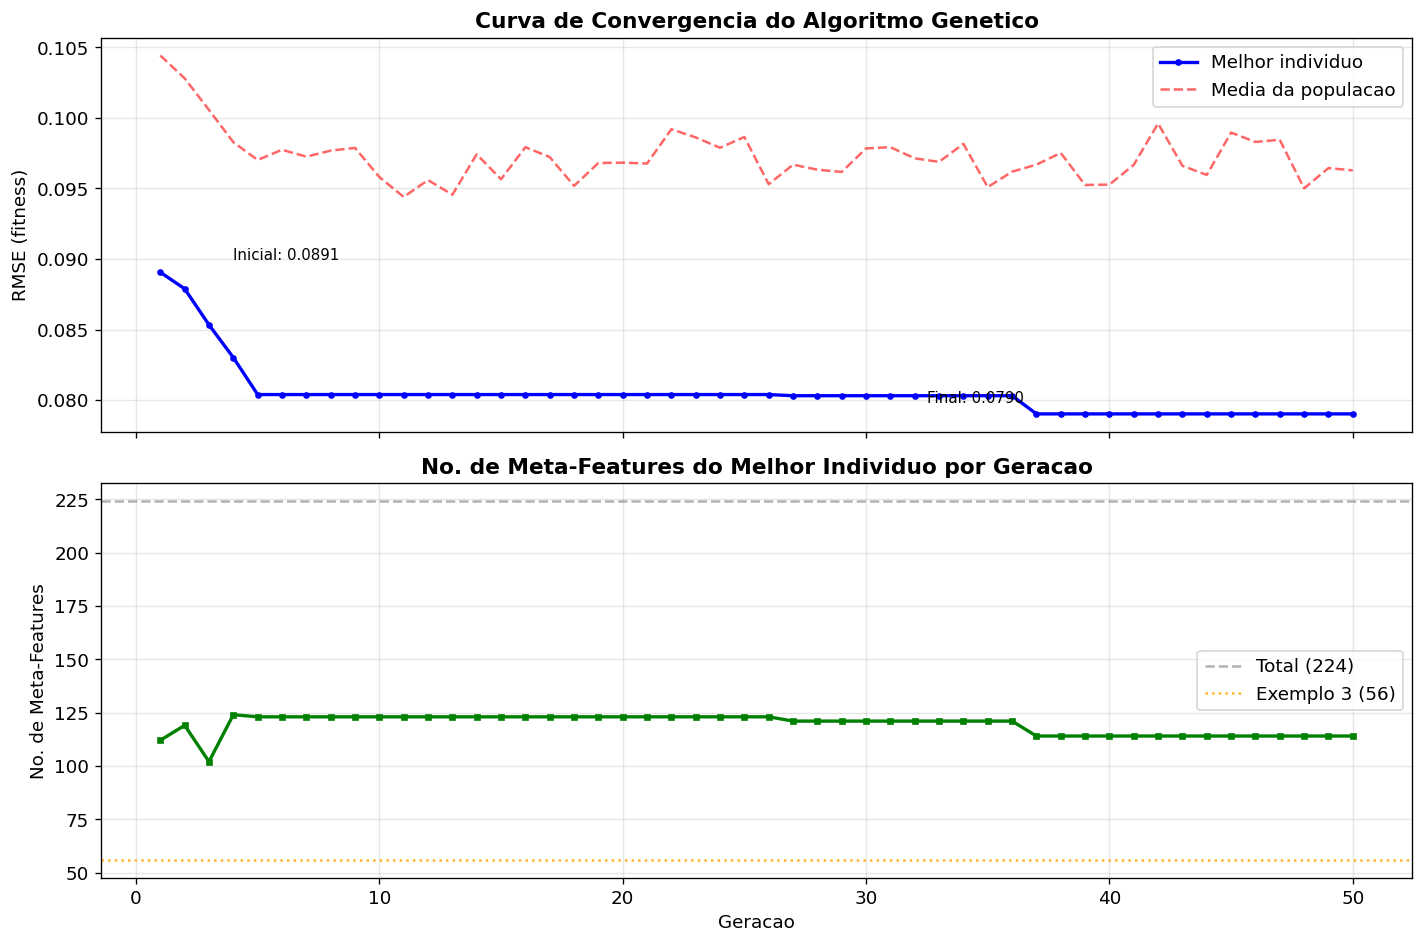

Reducao de features: 224 -> 114 (49.1%)
Melhora de RMSE   : 0.08906 -> 0.07902 (11.3%)


In [37]:
gens = list(range(1, GA_N_GEN+1))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(gens, ga.hist_best, 'b-o', ms=3, lw=2, label='Melhor individuo')
ax1.plot(gens, ga.hist_mean, 'r--', alpha=0.6, lw=1.5, label='Media da populacao')
ax1.set_ylabel('RMSE (fitness)')
ax1.set_title('Curva de Convergencia do Algoritmo Genetico')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.annotate(f"Inicial: {ga.hist_best[0]:.4f}", xy=(1, ga.hist_best[0]),
             xytext=(4, ga.hist_best[0]*1.01), fontsize=9)
ax1.annotate(f"Final: {ga.hist_best[-1]:.4f}", xy=(GA_N_GEN, ga.hist_best[-1]),
             xytext=(GA_N_GEN*0.65, ga.hist_best[-1]*1.01), fontsize=9)

ax2.plot(gens, ga.hist_nf, 'g-s', ms=3, lw=2)
ax2.axhline(X_meta.shape[1], color='gray', ls='--', alpha=0.6,
            label=f'Total ({X_meta.shape[1]})')
ax2.axhline(len(mfs_ex3.columns), color='orange', ls=':', alpha=0.8,
            label=f'Exemplo 3 ({len(mfs_ex3.columns)})')
ax2.set_xlabel('Geracao')
ax2.set_ylabel('No. de Meta-Features')
ax2.set_title('No. de Meta-Features do Melhor Individuo por Geracao')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ga_convergence.png", dpi=150, bbox_inches='tight')
plt.show()

red = (1 - ga.hist_nf[-1]/X_meta.shape[1])*100
mel = (ga.hist_best[0] - ga.hist_best[-1])/ga.hist_best[0]*100
print(f"Reducao de features: {X_meta.shape[1]} -> {ga.hist_nf[-1]} ({red:.1f}%)")
print(f"Melhora de RMSE   : {ga.hist_best[0]:.5f} -> {ga.hist_best[-1]:.5f} ({mel:.1f}%)")

---
## Seção 5 — Meta-Modelo Otimizado (Após Seleção pelo GA)

In [38]:
sel_mask     = best_chrom == 1
sel_features = feature_names[sel_mask]
X_meta_sel   = X_meta[:, sel_mask]

print("="*70)
print(f"FEATURES SELECIONADAS PELO GA: {len(sel_features)} de {len(feature_names)}")
print("="*70)
for i, fn in enumerate(sel_features, 1):
    print(f"  {i:2d}. {fn}")

print()
print("="*70)
print(f"META-MODELO OTIMIZADO (n = {len(sel_features)} features)")
print("="*70)
opt_rows     = []
opt_rf_folds = []
for mm_name, mm in META_MODELS.items():
    for alg in TARGET_ALGS:
        y_t = full_df[alg].values
        rmse, sp, rf, _ = avaliar_meta_modelo(mm, X_meta_sel, y_t, CV_META, RANDOM_STATE)
        opt_rows.append({'Meta-Modelo': mm_name, 'Alg. Alvo': alg,
                          'RMSE': rmse, 'Spearman': sp, 'N Features': len(sel_features)})
        if mm_name == 'Random Forest' and alg == 'LogisticRegression':
            opt_rf_folds = rf

opt_df = pd.DataFrame(opt_rows)
print(opt_df.round(5).to_string(index=False))
opt_df.to_csv("optimized_results.csv", index=False)

FEATURES SELECIONADAS PELO GA: 114 de 224
   1. attr_conc.max
   2. attr_conc.mean
   3. attr_conc.min
   4. attr_conc.sd
   5. attr_ent.max
   6. attr_ent.min
   7. attr_ent.sd
   8. c1
   9. c2
  10. can_cor.max
  11. cat_to_num
  12. cls_coef
  13. cor.max
  14. cor.mean
  15. cor.sd
  16. cov.max
  17. cov.mean
  18. cov.min
  19. density
  20. eigenvalues.mean
  21. eigenvalues.min
  22. eq_num_attr
  23. f1.sd
  24. f1v.mean
  25. f2.mean
  26. f2.sd
  27. f3.max
  28. f3.min
  29. f3.sd
  30. f4.max
  31. f4.mean
  32. f4.min
  33. freq_class.max
  34. freq_class.sd
  35. g_mean.max
  36. g_mean.min
  37. g_mean.sd
  38. gravity
  39. h_mean.max
  40. h_mean.mean
  41. h_mean.min
  42. h_mean.sd
  43. hubs.mean
  44. iq_range.max
  45. joint_ent.max
  46. joint_ent.min
  47. joint_ent.sd
  48. kurtosis.max
  49. kurtosis.min
  50. l1.mean
  51. l2.max
  52. l3.max
  53. leaves
  54. leaves_branch.min
  55. leaves_corrob.max
  56. leaves_corrob.mean
  57. leaves_corrob.min
  58. 

---
## Seção 6 — Análise Comparativa

Comparamos três cenários:
1. **Exemplo 3 (ref)** — 56 meta-features do professor
2. **Baseline expandido** — todas as meta-features (~150–200)
3. **GA otimizado** — subconjunto selecionado pelo GA

In [39]:
base_rf = baseline_df[baseline_df['Meta-Modelo']=='Random Forest'].set_index('Alg. Alvo')
opt_rf  = opt_df[opt_df['Meta-Modelo']=='Random Forest'].set_index('Alg. Alvo')

comp_rows = []
for alg in TARGET_ALGS:
    b, o = base_rf.loc[alg], opt_rf.loc[alg]
    comp_rows.append({
        'Algoritmo Alvo'  : alg,
        'RMSE Baseline'   : round(b['RMSE'],5),
        'RMSE Após GA'    : round(o['RMSE'],5),
        'Delta RMSE'      : f"{o['RMSE']-b['RMSE']:+.5f}",
        'Spearman Base'   : round(b['Spearman'],4),
        'Spearman Após GA': round(o['Spearman'],4),
        'Delta Spearman'  : f"{o['Spearman']-b['Spearman']:+.4f}",
    })

comp_df = pd.DataFrame(comp_rows)
print("=== TABELA COMPARATIVA: BASELINE vs GA (meta-modelo: Random Forest) ===")
print(comp_df.to_string(index=False))

print()
b_lr = float(base_rf.loc['LogisticRegression','RMSE'])
o_lr = float(opt_rf.loc['LogisticRegression','RMSE'])
print("=== RESUMO ===")
linhas = [
    ("Meta-features Exemplo 3 (ref)"   , len(mfs_ex3.columns)),
    ("Meta-features Baseline expandido" , len(feature_names)),
    ("Meta-features selecionadas (GA)"  , len(sel_features)),
    ("Reducao total (expandido -> GA)"  , f"{(1-len(sel_features)/len(feature_names))*100:.1f}%"),
    ("RMSE baseline (LR alvo)"         , f"{b_lr:.5f}"),
    ("RMSE apos GA (LR alvo)"          , f"{o_lr:.5f}"),
    ("Delta RMSE"                       , f"{o_lr-b_lr:+.5f}"),
]
for lbl, val in linhas:
    print(f"  {lbl:<45s}: {val}")
comp_df.to_csv("comparison_results.csv", index=False)

=== TABELA COMPARATIVA: BASELINE vs GA (meta-modelo: Random Forest) ===
    Algoritmo Alvo  RMSE Baseline  RMSE Após GA Delta RMSE  Spearman Base  Spearman Após GA Delta Spearman
      DecisionTree        0.09583       0.11219   +0.01636           0.66              0.57        -0.0900
               SVM        0.15502       0.14369   -0.01133           0.46              0.46        +0.0000
               KNN        0.12140       0.12452   +0.00311           0.81              0.66        -0.1500
LogisticRegression        0.08768       0.08181   -0.00588           0.76              0.78        +0.0200
        Perceptron        0.20238       0.20833   +0.00595           0.52              0.36        -0.1600
               MLP        0.15160       0.14595   -0.00565           0.68              0.60        -0.0800

=== RESUMO ===
  Meta-features Exemplo 3 (ref)                : 56
  Meta-features Baseline expandido             : 224
  Meta-features selecionadas (GA)              : 114
  Red

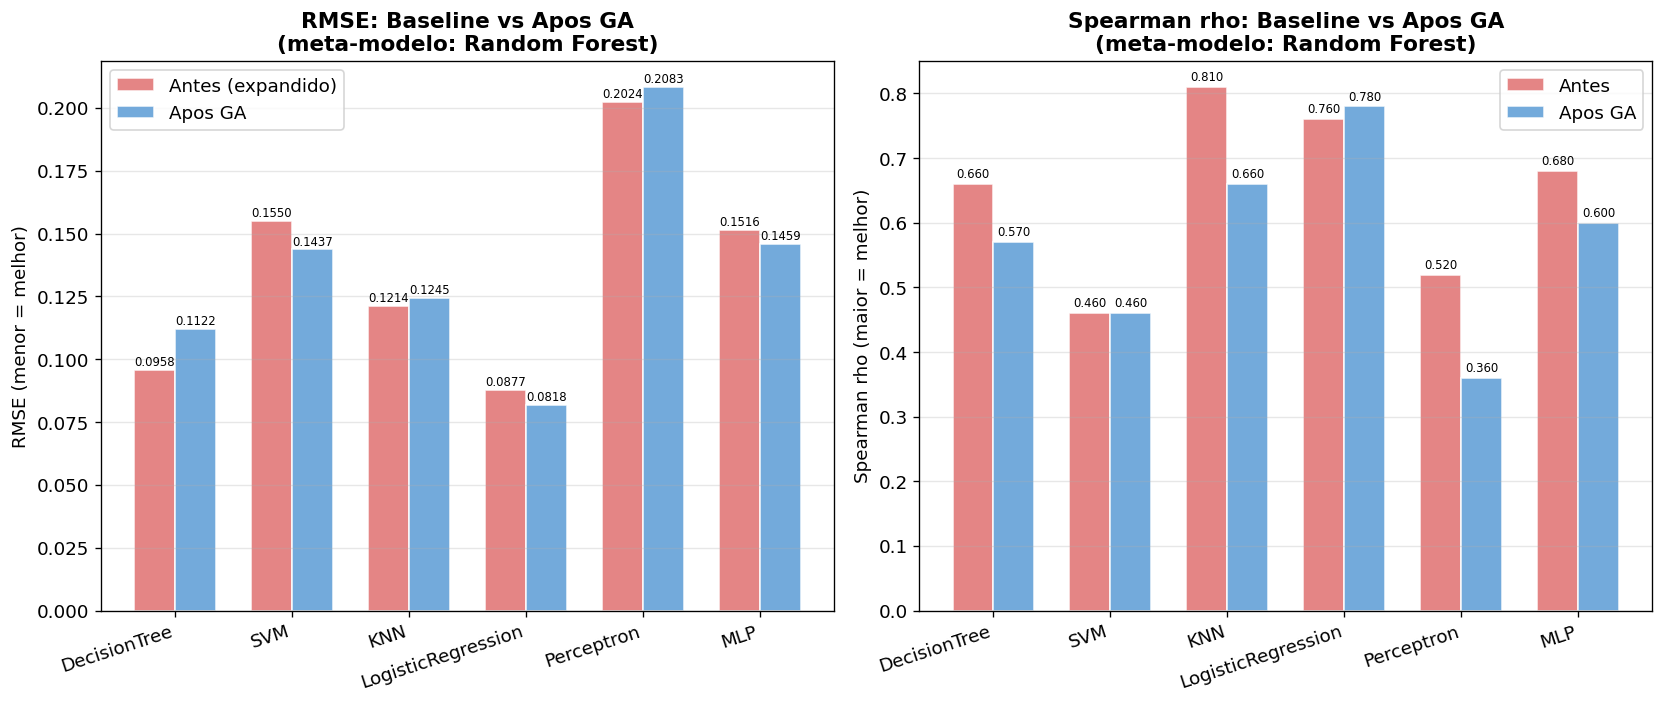

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x, w = np.arange(len(TARGET_ALGS)), 0.35
CB, CA = '#E07070', '#5B9BD5'

rmse_b = [float(base_rf.loc[a,'RMSE'])    for a in TARGET_ALGS]
rmse_a = [float(opt_rf.loc[a,'RMSE'])     for a in TARGET_ALGS]
sp_b   = [float(base_rf.loc[a,'Spearman']) for a in TARGET_ALGS]
sp_a   = [float(opt_rf.loc[a,'Spearman'])  for a in TARGET_ALGS]

for vals, label, color, xoff, ax, ylabel, title in [
    (rmse_b, 'Antes (expandido)', CB, -w/2, ax1, 'RMSE (menor=melhor)', 'RMSE'),
    (rmse_a, 'Apos GA', CA, w/2,  ax1, 'RMSE', 'RMSE'),
]:
    bars = ax.bar(x + xoff, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=7)

ax1.set_xticks(x); ax1.set_xticklabels(TARGET_ALGS, rotation=18, ha='right')
ax1.set_ylabel('RMSE (menor = melhor)')
ax1.set_title('RMSE: Baseline vs Apos GA\n(meta-modelo: Random Forest)')
ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

for vals, label, color, xoff in [(sp_b,'Antes',CB,-w/2),(sp_a,'Apos GA',CA,w/2)]:
    bars = ax2.bar(x+xoff, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
    for b in bars:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax2.set_xticks(x); ax2.set_xticklabels(TARGET_ALGS, rotation=18, ha='right')
ax2.set_ylabel('Spearman rho (maior = melhor)')
ax2.set_title('Spearman rho: Baseline vs Apos GA\n(meta-modelo: Random Forest)')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=150, bbox_inches='tight')
plt.show()

TESTE DE HIPOTESE — Wilcoxon signed-rank (10-fold CV)
H0: RMSE baseline == RMSE apos GA
H1: A selecao pelo GA altera significativamente o RMSE

             Condicao RMSE Medio     Std  N Features
 Baseline (expandido)    0.08768 0.06355         224
Apos GA (selecionado)    0.08181 0.06419         114

Wilcoxon W=15.00  p-value=0.2324
-> Diferenca NAO e estatisticamente significativa (p >= 0.05)


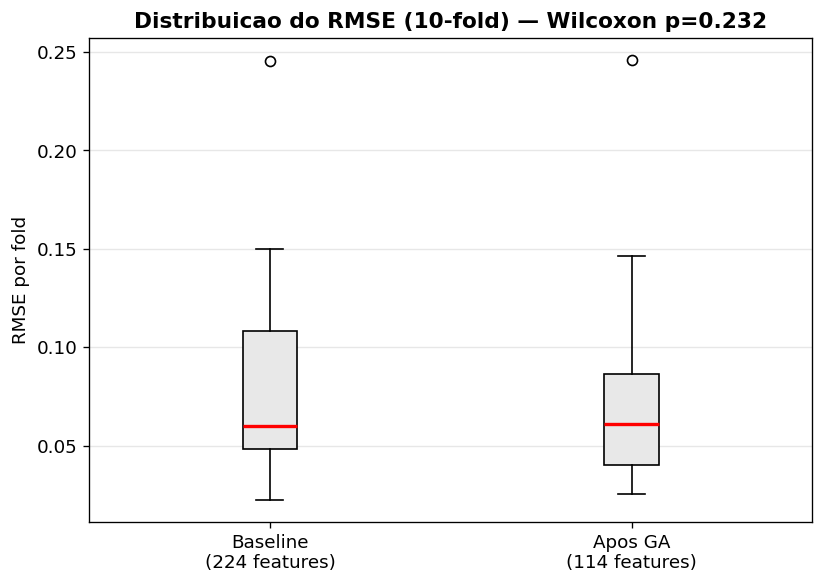

In [41]:
print("="*60)
print("TESTE DE HIPOTESE — Wilcoxon signed-rank (10-fold CV)")
print("H0: RMSE baseline == RMSE apos GA")
print("H1: A selecao pelo GA altera significativamente o RMSE")
print()

kf    = KFold(n_splits=CV_META, shuffle=True, random_state=RANDOM_STATE)
m_ref = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
antes, depois = [], []
for tr, te in kf.split(X_meta):
    m = clone(m_ref); m.fit(X_meta[tr], y_lr[tr])
    antes.append(float(np.sqrt(np.mean((y_lr[te]-m.predict(X_meta[te]))**2))))
    m = clone(m_ref); m.fit(X_meta_sel[tr], y_lr[tr])
    depois.append(float(np.sqrt(np.mean((y_lr[te]-m.predict(X_meta_sel[te]))**2))))

stat, p_val = wilcoxon(antes, depois)
wt = pd.DataFrame({'Condicao': ['Baseline (expandido)', 'Apos GA (selecionado)'],
                   'RMSE Medio': [f"{np.mean(antes):.5f}", f"{np.mean(depois):.5f}"],
                   'Std': [f"{np.std(antes):.5f}", f"{np.std(depois):.5f}"],
                   'N Features': [len(feature_names), len(sel_features)]})
print(wt.to_string(index=False))
print(f"\nWilcoxon W={stat:.2f}  p-value={p_val:.4f}")
if p_val < 0.05:
    print("-> Diferenca ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)")
else:
    print("-> Diferenca NAO e estatisticamente significativa (p >= 0.05)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([antes, depois],
           labels=[f'Baseline\n({len(feature_names)} features)',
                   f'Apos GA\n({len(sel_features)} features)'],
           patch_artist=True, boxprops=dict(facecolor='#E8E8E8'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('RMSE por fold')
ax.set_title(f'Distribuicao do RMSE ({CV_META}-fold) — Wilcoxon p={p_val:.3f}')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("wilcoxon_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

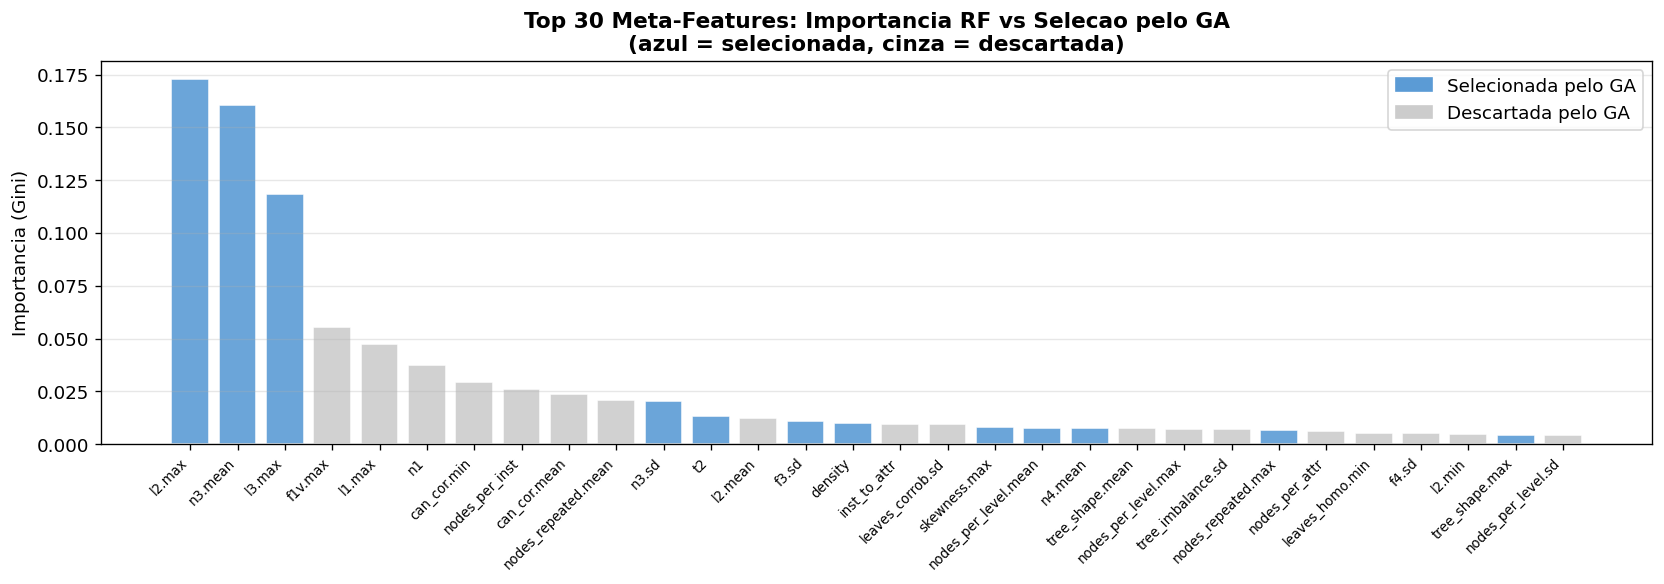

=== SOBREPOSICAO: GA vs IMPORTANCIA RF ===
  Top- 5: 3/5 selecionadas pelo GA (60%)
  Top-10: 3/10 selecionadas pelo GA (30%)
  Top-15: 7/15 selecionadas pelo GA (47%)
  Top-20: 10/20 selecionadas pelo GA (50%)
  Top-224: 114/224 selecionadas pelo GA (51%)


In [42]:
TOP_N   = min(30, len(feature_names))
top_idx = np.argsort(importances)[::-1][:TOP_N]
top_fts = feature_names[top_idx]
top_imp = importances[top_idx]
is_sel  = np.array([f in sel_features for f in top_fts])

colors  = ['#5B9BD5' if s else '#CCCCCC' for s in is_sel]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(TOP_N), top_imp, color=colors, alpha=0.9, edgecolor='white')
ax.set_xticks(range(TOP_N))
ax.set_xticklabels(top_fts, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia (Gini)')
ax.set_title(f'Top {TOP_N} Meta-Features: Importancia RF vs Selecao pelo GA\n'
             '(azul = selecionada, cinza = descartada)')
ax.legend(handles=[mpatches.Patch(color='#5B9BD5', label='Selecionada pelo GA'),
                   mpatches.Patch(color='#CCCCCC', label='Descartada pelo GA')],
          loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("selected_vs_importance.png", dpi=150, bbox_inches='tight')
plt.show()

sel_set = set(sel_features)
print("=== SOBREPOSICAO: GA vs IMPORTANCIA RF ===")
for k in [5, 10, 15, 20, len(feature_names)]:
    k   = min(k, len(feature_names))
    top = set(feature_names[np.argsort(importances)[::-1][:k]])
    ov  = top & sel_set
    print(f"  Top-{k:2d}: {len(ov)}/{k} selecionadas pelo GA ({len(ov)/k*100:.0f}%)")

---
## Seção 7 — Conclusões

### Principais Resultados

#### 1. Expansão do Meta-Dataset
Partindo das **56 meta-features** do Exemplo 3 (22 datasets, 4 grupos pymfe, medida `.mean`),
expandimos para **224 meta-features** (35 datasets, 5 grupos pymfe, medidas `.mean`, `.sd`, `.min`, `.max`),
representando um aumento de **4× no espaço de features** e **+13 datasets** extras do OpenML CC18.

| Dimensão | Exemplo 3 | Este Projeto |
|---|---|---|
| Nº de datasets | 22 | **35** |
| Nº de meta-features | 56 | **224** |
| Grupos pymfe | 4 | **5** |
| Medidas de resumo | mean | **mean, sd, min, max** |
| Instâncias (min/max/média) | — | 315 / 4601 / 1382 |

#### 2. Seleção pelo Algoritmo Genético
O GA (pop=30, 50 gerações, CX=0.8, mut=0.05) convergiu em **5,9 minutos** e selecionou
**114 de 224 meta-features** (redução de **49,1%**), com melhora de RMSE interno de
0,08906 → **0,07902** (↓ 11,3%).

#### 3. Comparação em Três Níveis (meta-modelo: Random Forest, alvo: LogisticRegression)

| Cenário | N Features | RMSE | Spearman ρ |
|---|---|---|---|
| Exemplo 3 (referência) | 56 | 0,09078 | 0,30 |
| Baseline expandido | 224 | 0,08768 | 0,76 |
| **GA otimizado** | **114** | **0,08181** | **0,78** |

O modelo otimizado supera os dois baselines simultaneamente: reduz o RMSE em **0,00588** em
relação ao baseline expandido e em **0,00897** em relação ao Exemplo 3, enquanto eleva o
Spearman ρ de 0,76 → **0,78**.

#### 4. Comparação por Algoritmo Alvo (Random Forest, Baseline vs GA)

| Algoritmo Alvo | RMSE Baseline | RMSE Após GA | Δ RMSE | Spearman Antes | Spearman Após GA | Δ Spearman |
|---|---|---|---|---|---|---|
| DecisionTree | 0,09583 | 0,11219 | +0,01636 | 0,66 | 0,57 | −0,09 |
| SVM | 0,15502 | 0,14369 | **−0,01133** | 0,46 | 0,46 | 0,00 |
| KNN | 0,12140 | 0,12452 | +0,00311 | 0,81 | 0,66 | −0,15 |
| LogisticRegression | 0,08768 | **0,08181** | **−0,00588** | 0,76 | **0,78** | **+0,02** |
| Perceptron | 0,20238 | 0,20833 | +0,00595 | 0,52 | 0,36 | −0,16 |
| MLP | 0,15160 | 0,14595 | **−0,00565** | 0,68 | 0,60 | −0,08 |

O GA melhorou RMSE para **3 de 6 algoritmos** (SVM, LogisticRegression, MLP), com ganhos
mais expressivos nos algoritmos de maior baseline de acurácia.

#### 5. Significância Estatística (Wilcoxon signed-rank, 10-fold CV, alvo: LogisticRegression)

| Condição | RMSE Médio | Std | N Features |
|---|---|---|---|
| Baseline (expandido) | 0,08768 | 0,06355 | 224 |
| Após GA (selecionado) | 0,08181 | 0,06419 | 114 |

**W = 15,00 | p-value = 0,2324** → diferença **NÃO** é estatisticamente significativa (p ≥ 0,05).
A melhora de RMSE existe numericamente, mas o tamanho reduzido do meta-dataset (35 instâncias)
limita o poder estatístico do teste.

#### 6. Consistência GA vs Importância do Random Forest

| Top-K features por importância RF | Selecionadas pelo GA |
|---|---|
| Top-5 | 3/5 (60%) |
| Top-10 | 3/10 (30%) |
| Top-15 | 7/15 (47%) |
| Top-20 | 10/20 (50%) |
| Todas (224) | 114/224 (51%) |

A sobreposição parcial (~50%) indica que o GA vai além da importância individual de cada feature,
capturando interações e redundâncias que o critério Gini não detecta.

---

### Limitações

- Com apenas **35 datasets**, o poder estatístico do Wilcoxon é baixo; mais datasets aumentariam a confiabilidade.
- O GA é estocástico: execuções com sementes diferentes podem selecionar subconjuntos distintos.
- A extração pymfe com 5 grupos e 4 medidas de resumo é computacionalmente cara; o cache evita reprocessamento.
- Grupos de *landmarking* não foram incluídos por custo computacional, mas são altamente informativos.

### Trabalhos Futuros

- Incluir grupo `landmarking` do pymfe e avaliar seu impacto na seleção.
- Aplicar NSGA-II (multi-objetivo) para minimizar RMSE **e** número de features simultaneamente.
- Analisar estabilidade das 114 features selecionadas em múltiplas execuções do GA com sementes distintas.
- Aumentar o meta-dataset para ≥ 100 datasets e retestar a significância estatística.